# 00 — UC2 Data Analysis & Partition Generation

**Use Case 2**: Wi-Fi AP Load Prediction (FLAG dataset)

This notebook:
1. Loads and explores the raw FLAG dataset
2. Visualizes AP load distributions
3. Generates Dirichlet-partitioned datasets for α ∈ {0.5, 1.0, 5.0, 10.0}

In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter


sys.path.insert(0, uc2.LIB_DIR)

## 1. Load Raw Dataset

**IMPORTANT**: Place the pickle file `pickle_2019-05-13-on7_2min.pkl` in `data/raw/`.
Get this file from Francesc.

In [2]:
raw_path = uc2.get_raw_dataset_path()
print(f"Loading dataset from: {raw_path}")

sys.path.insert(0, os.path.abspath(".."))
from data.FlagsRegression.dataset import load_dataset
raw_data = load_dataset(path=raw_path, cache=False)

print(f"\nDataset shape: {raw_data.shape}")
print(f"Columns: {list(raw_data.columns)}")
print(f"Date range: {raw_data['datetime'].min()} → {raw_data['datetime'].max()}")
print(f"Number of unique APs: {raw_data['AP ID'].nunique()}")
print(f"\nFirst rows:")
raw_data.head()

Loading dataset from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/raw/pickle_2019-05-13-on7_10min.pkl


100%|██████████| 2557/2557 [18:27<00:00,  2.31it/s]



Dataset shape: (2641932, 12)
Columns: ['datetime', 'Index', 'Bytes', 'Active Connections', 'Active Users', 'AP ID', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'hour_of_day', 'hour_of_day_sin', 'hour_of_day_cos']
Date range: 2019-04-22 15:00:00 → 2019-05-15 03:10:00
Number of unique APs: 2546

First rows:


,datetime,Index,Bytes,Active Connections,Active Users,AP ID,day_of_week,day_of_week_sin,day_of_week_cos,hour_of_day,hour_of_day_sin,hour_of_day_cos
0,2019-04-29 23:50:00,0,-13.0,1.000000,0.0,7-2324,0,0.000000,1.0,23,-2.449294e-16,1.000000
3,2019-04-30 00:20:00,3,-13.0,1.316667,0.0,7-2324,1,0.866025,0.5,0,0.000000e+00,1.000000
5,2019-04-30 00:40:00,5,-13.0,0.696667,0.0,7-2324,1,0.866025,0.5,0,0.000000e+00,1.000000
6,2019-04-30 00:50:00,6,-13.0,0.000000,0.0,7-2324,1,0.866025,0.5,0,0.000000e+00,1.000000
8,2019-04-30 01:10:00,8,-13.0,0.008333,0.0,7-2324,1,0.866025,0.5,1,2.697968e-01,0.962917


In [3]:
# Basic statistics
print("=== Target variable: Bytes ===")
print(raw_data["Bytes"].describe())
print(f"\nZero-load samples: {(raw_data['Bytes'] == 0).sum()} "
      f"({(raw_data['Bytes'] == 0).mean()*100:.1f}%)")
print(f"\n=== Active Users ===")
print(raw_data["Active Users"].describe())

=== Target variable: Bytes ===
count    2.641932e+06
mean    -4.051081e+00
std      6.767115e+00
min     -1.300000e+01
25%     -1.300000e+01
50%      5.479852e-02
75%      1.496060e+00
max      3.814321e+00
Name: Bytes, dtype: float64

Zero-load samples: 3 (0.0%)

=== Active Users ===
count    2.641932e+06
mean     2.087835e+00
std      4.106880e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.100000e+02
Name: Active Users, dtype: float64


## 2. Visualize AP Load Distributions
Reproducing Figure 2 from the paper — histograms + KDE for sample APs

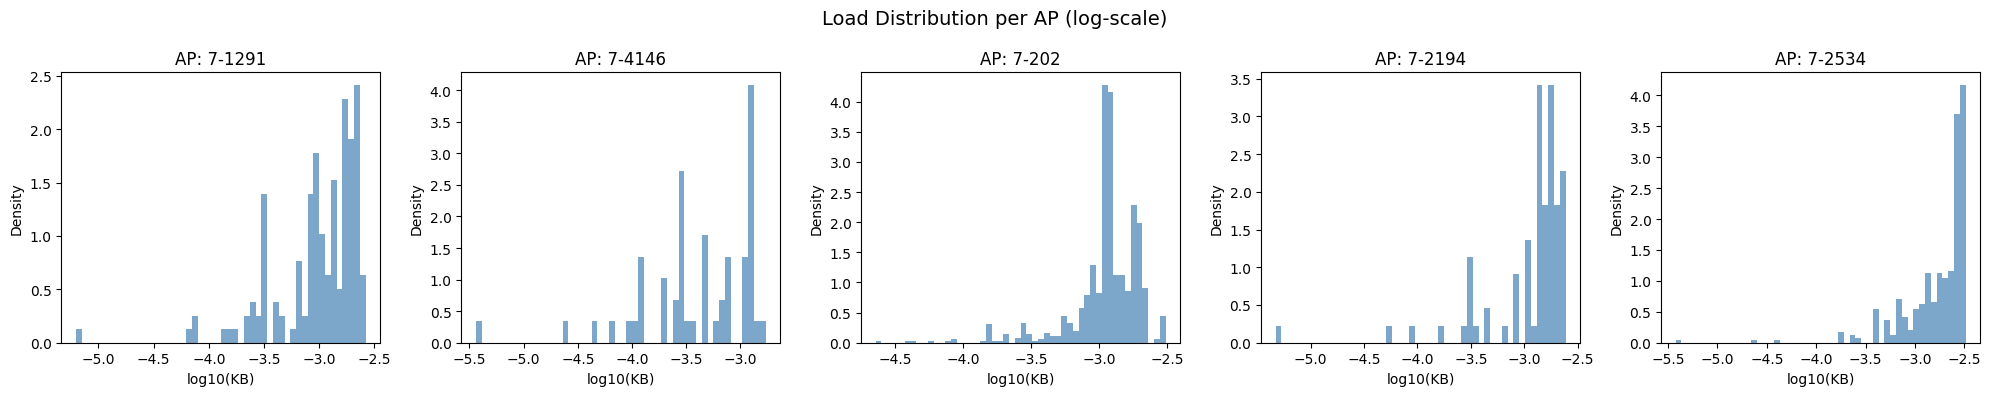

In [4]:
unique_aps = raw_data["AP ID"].unique()
sample_aps = np.random.choice(unique_aps, min(5, len(unique_aps)), replace=False)

fig, axes = plt.subplots(1, len(sample_aps), figsize=(4*len(sample_aps), 4))
if len(sample_aps) == 1:
    axes = [axes]

for ax, ap_id in zip(axes, sample_aps):
    ap_data = raw_data[raw_data["AP ID"] == ap_id]["Bytes"]
    # Log-transform for better visualization (as done in preprocessing)
    ap_log = np.log10(ap_data[ap_data > 0] * 1e-3)
    ax.hist(ap_log, bins=50, density=True, alpha=0.7, color="steelblue")
    ax.set_title(f"AP: {ap_id}")
    ax.set_xlabel("log10(KB)")
    ax.set_ylabel("Density")

plt.suptitle("Load Distribution per AP (log-scale)", fontsize=14)
plt.tight_layout()
plt.show()

Samples per AP — min: 2, max: 3234, median: 802


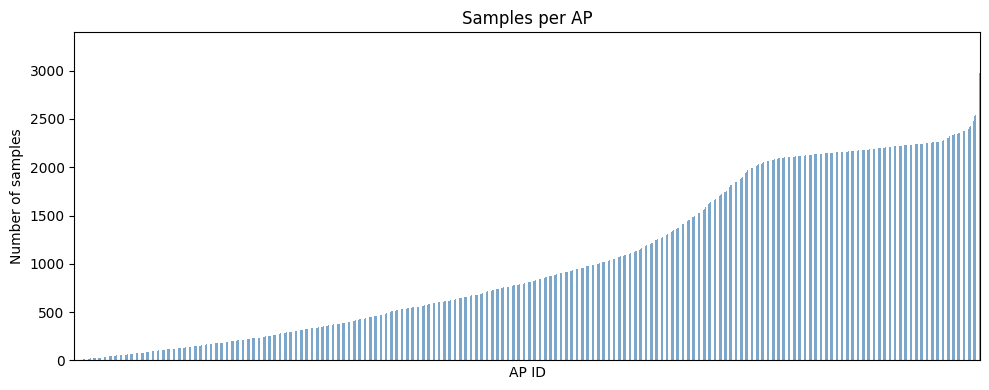

In [5]:
# Samples per AP
samples_per_ap = raw_data.groupby("AP ID").size()
print(f"Samples per AP — min: {samples_per_ap.min()}, max: {samples_per_ap.max()}, "
      f"median: {samples_per_ap.median():.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
samples_per_ap.sort_values().plot(kind="bar", ax=ax, color="steelblue", alpha=0.7)
ax.set_xlabel("AP ID")
ax.set_ylabel("Number of samples")
ax.set_title("Samples per AP")
ax.set_xticks([])  # too many APs to label
plt.tight_layout()
plt.show()

## 3. Feature Engineering
The preprocessing pipeline (from `dataset.py`) does:
- Zero balancing: downsample zero-load rows to match non-zero count per AP
- Log transform: `Bytes → log10(Bytes * 1e-3)`
- Cyclical encoding: day_of_week and hour_of_day → sin/cos
- MinMax scaling to [1, 2]
- Time series windowing: lookback=60, steps={1,5,15,30}

**Features (6)**: Bytes, day_of_week_sin, day_of_week_cos, 
hour_of_day_sin, hour_of_day_cos, Active Users

In [6]:
features = ["Bytes", "day_of_week_sin", "day_of_week_cos",
            "hour_of_day_sin", "hour_of_day_cos", "Active Users"]
print("Feature columns used for training:")
for f in features:
    print(f"  {f}: range [{raw_data[f].min():.4f}, {raw_data[f].max():.4f}]")

Feature columns used for training:
  Bytes: range [-13.0000, 3.8143]
  day_of_week_sin: range [-0.8660, 0.8660]
  day_of_week_cos: range [-1.0000, 1.0000]
  hour_of_day_sin: range [-0.9977, 0.9977]
  hour_of_day_cos: range [-0.9907, 1.0000]
  Active Users: range [0.0000, 110.0000]


## 4. Generate Dirichlet Partitions

For each α ∈ {0.5, 1.0, 5.0, 10.0}, generate partitioned data
across 20 users (deployments). Lower α = more heterogeneity.

In [7]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
LOOKBACK = 60
STEPS = 1
regenerate= False

for alpha in ALPHAS:
    if regenerate or not uc2.partitions_exist(alpha=alpha, lookback=LOOKBACK, steps=STEPS):
        uc2.generate_partitions(alpha=alpha, lookback=LOOKBACK, steps=STEPS)
    else:    
        print(f"Partitions for alpha={alpha} already exist. Skipping generation.")

[…] Generating partitions for α=0.01, 20 users, lookback=60, steps=1
 * Total data set samples: 2641932
      - APs for training/validation: ['7-1651', '7-933', '7-324', '7-3838', '7-2551', '7-2294', '7-199', '7-662', '7-4132', '7-864', '7-1642', '7-1899', '7-3973', '7-701', '7-2559', '7-2540', '7-40', '7-2507', '7-178', '7-2864', '7-2937', '7-640', '7-460', '7-496', '7-1022', '7-1002', '7-575', '7-1209', '7-3057', '7-4191', '7-3928', '7-238', '7-527', '7-621', '7-156', '7-1230', '7-678', '7-2016', '7-3085', '7-4170', '7-3428', '7-1736', '7-1900', '7-1071', '7-842', '7-2905', '7-2068', '7-317', '7-437', '7-1809', '7-936', '7-391', '7-584', '7-3868', '7-2780', '7-3028', '7-2778', '7-895', '7-1106', '7-2697', '7-381', '7-1841', '7-274', '7-106', '7-1462', '7-1727', '7-4096', '7-511', '7-3610', '7-372', '7-1268', '7-2912', '7-104', '7-2157', '7-924', '7-1886', '7-670', '7-2037', '7-1442', '7-610', '7-313', '7-2677', '7-1040', '7-1278', '7-1455', '7-186', '7-745', '7-88', '7-2101', '7-1748

100%|██████████| 20/20 [00:02<00:00,  9.76it/s]


    train: [5539, 5524, 2925, 4712, 5164, 5241, 2123, 4710, 5493, 4458, 4964, 4772, 4483, 4860, 3759, 5676, 3008, 4168, 4753, 2562]
    test: [2265, 1680, 2182, 1574, 1917, 1112, 1514, 1076, 1145, 970, 1181, 1024, 1377, 888, 695, 415, 187, 482, 402, 138]
[✓] Saved partitions for α=0.01
    Samples per user: [5539, 5524, 2925, 4712, 5164, 5241, 2123, 4710, 5493, 4458, 4964, 4772, 4483, 4860, 3759, 5676, 3008, 4168, 4753, 2562]
[…] Generating partitions for α=0.1, 20 users, lookback=60, steps=1
 * Total data set samples: 2641932
      - APs for training/validation: ['7-1651', '7-933', '7-324', '7-3838', '7-2551', '7-2294', '7-199', '7-662', '7-4132', '7-864', '7-1642', '7-1899', '7-3973', '7-701', '7-2559', '7-2540', '7-40', '7-2507', '7-178', '7-2864', '7-2937', '7-640', '7-460', '7-496', '7-1022', '7-1002', '7-575', '7-1209', '7-3057', '7-4191', '7-3928', '7-238', '7-527', '7-621', '7-156', '7-1230', '7-678', '7-2016', '7-3085', '7-4170', '7-3428', '7-1736', '7-1900', '7-1071', '7-842'

100%|██████████| 20/20 [00:02<00:00,  9.92it/s]


    train: [4636, 3900, 4559, 4464, 3376, 4454, 4484, 2858, 4583, 3884, 5185, 4461, 4504, 4798, 5226, 5010, 3761, 4636, 4628, 5487]
    test: [9576, 6340, 3073, 1751, 910, 484, 0, 56, 34, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[✓] Saved partitions for α=0.1
    Samples per user: [4636, 3900, 4559, 4464, 3376, 4454, 4484, 2858, 4583, 3884, 5185, 4461, 4504, 4798, 5226, 5010, 3761, 4636, 4628, 5487]
Partitions for alpha=0.5 already exist. Skipping generation.
Partitions for alpha=1.0 already exist. Skipping generation.
Partitions for alpha=5.0 already exist. Skipping generation.
Partitions for alpha=10.0 already exist. Skipping generation.


## 5. Verify Partitions & Visualize Heterogeneity

In [8]:
import torch

for alpha in ALPHAS:
    part_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "train", "train.pt"
    )
    with open(part_path, "rb") as f:
        data = torch.load(f, weights_only=False)

    samples = data["num_samples"]
    print(f"\nα={alpha}: {len(samples)} users, "
          f"total={sum(samples)} samples")
    print(f"  per-user: min={min(samples)}, max={max(samples)}, "
          f"std={np.std(samples):.1f}, CV={np.std(samples)/np.mean(samples):.2f}")


α=0.01: 20 users, total=88894 samples
  per-user: min=2123, max=5676, std=1019.1, CV=0.23

α=0.1: 20 users, total=88894 samples
  per-user: min=2858, max=5487, std=615.3, CV=0.14

α=0.5: 20 users, total=88894 samples
  per-user: min=3684, max=5181, std=328.0, CV=0.07

α=1.0: 20 users, total=88894 samples
  per-user: min=3594, max=4869, std=262.4, CV=0.06

α=5.0: 20 users, total=88894 samples
  per-user: min=4018, max=4690, std=160.5, CV=0.04

α=10.0: 20 users, total=88894 samples
  per-user: min=4036, max=4632, std=131.1, CV=0.03


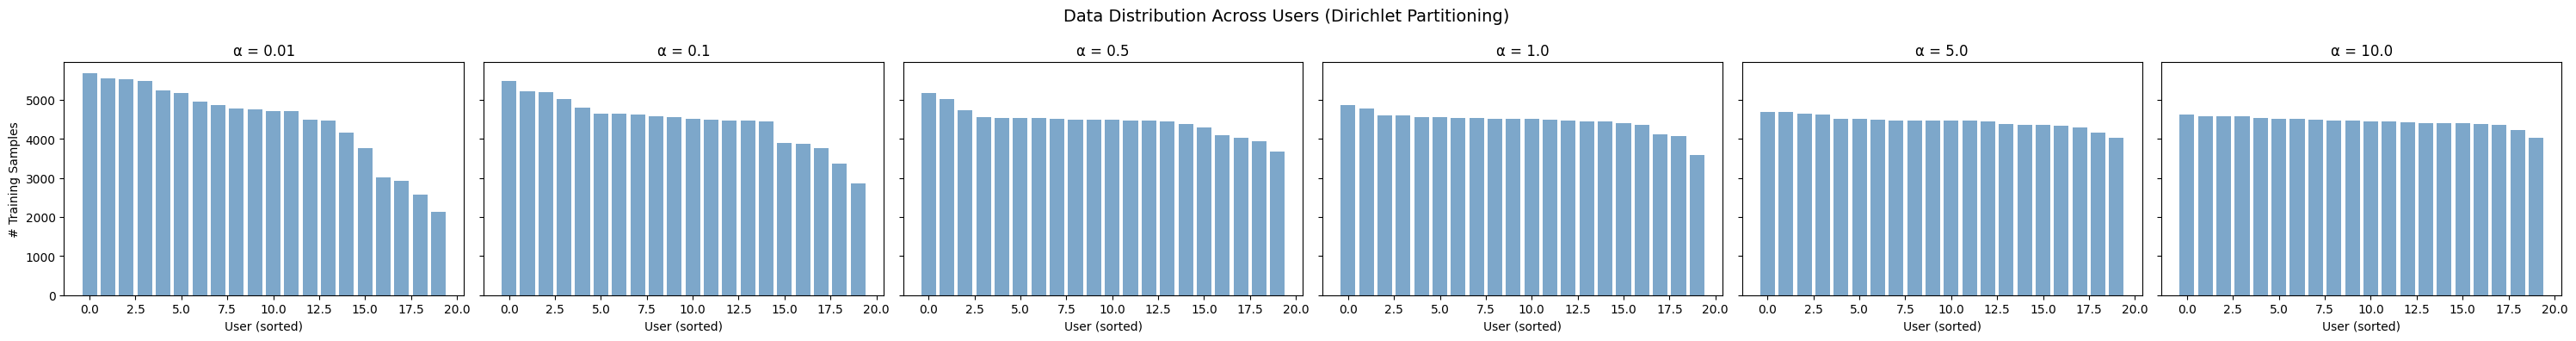

In [9]:
# Visualize sample distribution across users for each alpha
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5*len(ALPHAS), 4), sharey=True)

for ax, alpha in zip(axes, ALPHAS):
    part_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "train", "train.pt"
    )
    with open(part_path, "rb") as f:
        data = torch.load(f, weights_only=False)

    samples = data["num_samples"]
    ax.bar(range(len(samples)), sorted(samples, reverse=True),
           color="steelblue", alpha=0.7)
    ax.set_title(f"α = {alpha}")
    ax.set_xlabel("User (sorted)")
    if ax == axes[0]:
        ax.set_ylabel("# Training Samples")

plt.suptitle("Data Distribution Across Users (Dirichlet Partitioning)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

- Raw dataset loaded and explored: ~7400 APs, 49 days, 2-min windows
- Partitions generated for α ∈ {0.5, 1.0, 5.0, 10.0} with 20 users each
- Lower α → more heterogeneous distribution → harder FL problem
- Data saved in `data/partitions/lookback_60/steps_1/u20-alpha{α}-ratio1/`